In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.integrate  as integrate 
import extcurves
from scipy.optimize import bisect

from astropy import constants
eV  = 1.60218e-12  # eV --> erg
C = constants.c.cgs.value      # Speed of light (cm/s)
H = constants.h.cgs.value      # Planck constant (erg s)
K = constants.k_B.cgs.value    # Boltzmann constant (erg/K)
sigma_SB = constants.sigma_sb.cgs.value  # Stefan-Boltzmann constant in cgs units

In [2]:
def planck_function(wavelength, T):
    """Compute the blackbody radiation intensity using the Planck function
    
    Args:
        wavelength: Wavelength in meters.
        T: Temperature in Kelvin.
    
    Returns:
        Blackbody radiation intensity (energy density per unit wavelength).
    """
    # Avoid division by zero for wavelength or temperature
    wavelength = np.clip(wavelength, 1e-20, None)  # Prevent zero wavelengths
    if T<1e-6: T=1e-6 # Prevent zero or near-zero temperatures

    # Compute the exponential term safely
    exponent = H * C / (wavelength * K * T)
    safe_exponent = np.clip(exponent, None, 700)  # Clamp exponent to avoid overflow

    # Planck function
    B_lambda = (2 * H * C**2) / (wavelength**5) * (1. / (np.exp(safe_exponent) - 1.))
    return B_lambda

In [3]:
def radiation_UV(wavelength_A): # Draine's Field
    """Compute the UV radiation intensity based on Draine's field.

    Args:
        wavelength_A: Wavelength in Angstrom.

    Returns:
        float: UV radiation spectral density (erg cm-3).
    """

    lambda3 = wavelength_A/1000.
    return 6.84e-14 * lambda3**(-5) * (31.016 * lambda3**2 - 49.913 * lambda3 + 19.897) # erg cm-3

In [4]:
def radiation_intensity(wavelength, chi0=1):
    """Compute the radiation intensity for a given wavelength and scaling factor.

    Args:
        wavelength: Wavelength (cgs)
        chi0 (int, optional): Scaling factor for the radiation field (dimensionless). Defaults to 1 (typical ISRF).

    Returns:
        Specific radiation spectral density (erg cm-3 wavelength-1).
    """

    # Weighting factors and temperatures
    W = np.array([1e-14, 1.65e-13, 4e-13])  # Weighting factors (dimensionless)
    T = np.array([7500, 4000, 3000])        # Blackbody temperatures (Kelvin)
    

    B = np.array([planck_function(wavelength, Ti) for Ti in T])  # shape (n_T, n_wl)
    blackbody_components = (4 * np.pi/C) * np.sum(W[:, None] * B, axis=0)

    u_UV = radiation_UV(wavelength*1e8)/wavelength # erg cm-3 wavelength-1

    # Combine all contributions, scaling by factor chi0
    u_rad_lam = chi0 * (u_UV + blackbody_components) + (4*np.pi/C) * planck_function(wavelength,2.73)

    return u_rad_lam  # erg cm-3 wavelength-1

In [5]:
def radiative_heating(a,chi0,Av):
    """Compute the radiative heating rate for a dust grain.

    Args:
        a    : Grain radius (cm).
        chi0 : Incident radiation field strength (dimensionless).
        Av   : Visual extinction (mag).

    Returns:
        float: Radiative heating rate (erg s-1).
    """
    Rv=3.1

    #Qabsorption efficiency
    w_um, Qabs = np.loadtxt('Qabs_astrosil_Draine2003.txt', skiprows=5,unpack=True)
    w_cm = w_um * 1e-4  # convert from microns to cm

    mask = (w_cm >= 91.2e-7) & (w_cm <= 1000e-4) # Select wavelengths between 91.2 nm and 1000 microns
    w_cm = w_cm[mask]
    Qabs = Qabs[mask]
    w_um = w_um[mask]

    urad_wave = radiation_intensity(w_cm,chi0=chi0)  # erg cm-3 cm-1

    A_lambda_AV = extcurves.extcurve_obs(w_um, Rv)

    tau = Av * A_lambda_AV / 1.086  # optical depth
    urad_wave_red = urad_wave * np.exp(-tau)

    urad = integrate.trapezoid(urad_wave_red*Qabs,w_cm)
    return np.pi * a**2 * C * urad  # erg s-1

In [6]:
def radiative_cooling(a,Td):
    """Compute the radiative cooling rate for a dust grain.

    Args:
        a  : Grain radius (cm).
        Td : Dust temperature (K).

    Returns:
        Radiative cooling rate (erg s^-1).
    """
    
    #Qabsorption efficiency
    q_abs = 0.13
    
    return  4.0 * np.pi * q_abs * a**3 * sigma_SB * Td**6  # erg s^-1

In [7]:
def CR_heating(zeta, a):
    """Compute the cosmic ray heating rate for a dust grain.

    Args:
        zeta : Cosmic ray ionization rate (s^-1).
        a    : Grain radius (cm).

    Returns:
        Cosmic ray heating rate (erg s^-1).
    """
    
    RV = 3.1
    flux_CRUV = 100.0 * (5.023 - 0.504 * RV + 0.115 * RV**2) * (zeta/1e-17)  # particles cm-2 s-1
    # assuming each UV photon deposits 13 eV into the grain and isotropic flux (4*pi steradians)
    return  4*np.pi * 13 * eV * np.pi * a**2 * flux_CRUV  # erg s^-1

In [8]:
def Tdust_equilibrium_radiative(a,chi0, Av):
    """Compute the equilibrium dust temperature for a given grain size and radiation field.

    Args:
        a    : Grain radius (cm).
        chi0 : Incident radiation field strength (dimensionless).
        Av   : Visual extinction (mag).
    """
    def func(Td):
        urad_heat = radiative_heating(a, chi0, Av)
        urad_cool = radiative_cooling(a, Td)
        return urad_heat - urad_cool

    Td_eq = bisect(func, 2.73, 500.0, xtol=1e-5, maxiter=10000)
    
    return Td_eq

In [9]:
def Tdust_equilibrium_radiative_CR(a, chi0, Av, zeta):
    def func(Td):
        urad_heat = radiative_heating(a, chi0, Av)
        urad_cool = radiative_cooling(a, Td)
        cr_heat = CR_heating(zeta, a)
        return urad_heat + cr_heat - urad_cool

    from scipy.optimize import bisect
    Td_eq = bisect(func, 2.73, 500.0, xtol=1e-5, maxiter=10000)
    
    return Td_eq

In [10]:
def zeta_CR(Ngas, model='L'):
    if model == 'L':
        c = np.array([
            -3.331056497233e6,
            1.207744586503e6,
            -1.913914106234e5,
            1.731822350618e4,
            -9.790557206178e2,
            3.543830893824e1,
            -8.034869454520e-1,
            1.048808593086e-2,
            -6.188760100997e-5,
            3.122820990797e-8
        ])
    elif model=='H':
        c = np.array([1.001098610761e7,
                    -4.231294690194e6,
                        7.921914432011e5,
                    -8.623677095423e4,
                    6.015889127529e3,
                    -2.789238383353e2,
                    8.595814402406e0,
                    -1.698029737474e-1,
                    1.951179287567e-3,
                    -9.937499546711e-6
                    ])
    else:
        raise ValueError("Model must be 'L' or 'H'")

    x = np.log10(Ngas)
    log10_zeta= sum(c[k] * x**k for k in range(len(c)))

    zeta = 10**log10_zeta
    return zeta  # s^-1

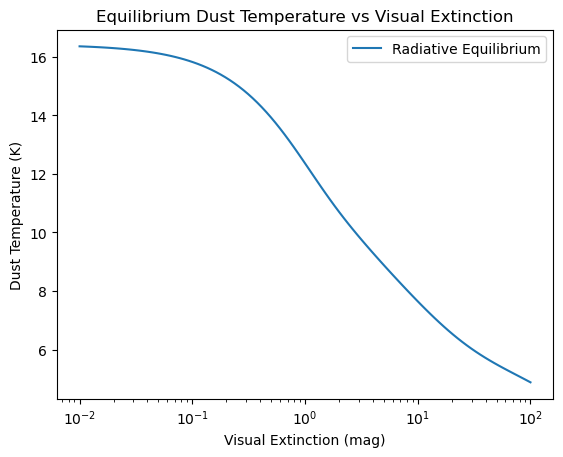

In [19]:
if __name__ == "__main__":
    a = 0.1e-4  # cm
    chi0=1.0    # typical ISRF
    Av_range = np.logspace(np.log10(0.01), np.log10(100.0), 100)
    zeta_scale = 1.0
        
    Td0 = [Tdust_equilibrium_radiative(a, chi0, Av) for Av in Av_range]

    plt.plot(Av_range, Td0, label='Radiative Equilibrium')
    plt.xscale('log')
    plt.xlabel('Visual Extinction (mag)')
    plt.ylabel('Dust Temperature (K)')
    plt.title('Equilibrium Dust Temperature vs Visual Extinction')
    plt.legend()
    plt.show()

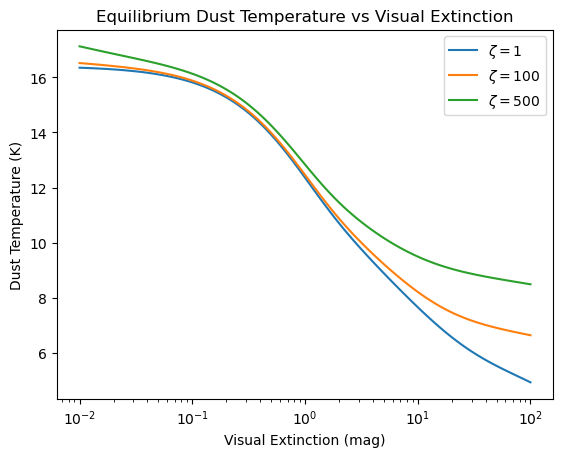

In [17]:
if __name__ == "__main__":
    a = 0.1e-4  # cm
    chi0=1.0    # typical ISRF
    Av_range = np.logspace(np.log10(0.01), np.log10(100.0), 100)
    # zeta_scale = 1.0
    Ngas_range = 1.6e21 * Av_range  # cm-2
    for zeta_scale in [1,100,500]:
        zeta_range = zeta_CR(Ngas_range, model='L') * zeta_scale  # s^-1
        Td0 = [Tdust_equilibrium_radiative_CR(a, chi0, Av, zeta) for Av, zeta in zip(Av_range, zeta_range)]
        
        # Td0 = [Tdust_equilibrium_radiative(a, chi0, Av) for Av in Av_range]

        # fig, ax= plt.subplots(figsize=(8,6))
        plt.plot(Av_range, Td0, label=f'$\zeta={zeta_scale:.0f}$')
    plt.xscale('log')
    plt.xlabel('Visual Extinction (mag)')
    plt.ylabel('Dust Temperature (K)')
    plt.title('Equilibrium Dust Temperature vs Visual Extinction')
    plt.legend()
    plt.show()